In [2]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D
from tensorflow.keras.layers import Flatten, Dense, Dropout
from tensorflow.keras.optimizers import Adam

import matplotlib.pyplot as plt
import numpy as np
import os

In [7]:
train_path = r"D:\python\git\Face-Emotion-Classification-CNN\dataset\training"
validation_path = r"D:\python\git\Face-Emotion-Classification-CNN\dataset\testing"

In [4]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    shear_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

validation_datagen = ImageDataGenerator(
    rescale=1./255
)

In [8]:
#load the training and validation data
train_dataset = train_datagen.flow_from_directory(
    train_path,
    target_size=(200, 200),
    batch_size=32,
    class_mode='binary',
    shuffle=True
)

validation_dataset = validation_datagen.flow_from_directory(
    validation_path,
    target_size=(200, 200),
    batch_size=32,
    class_mode='binary',
    shuffle=False
)

Found 143 images belonging to 2 classes.
Found 14 images belonging to 2 classes.


In [9]:
print("Class Labels:")

print(train_dataset.class_indices)

Class Labels:
{'happy': 0, 'sad': 1}


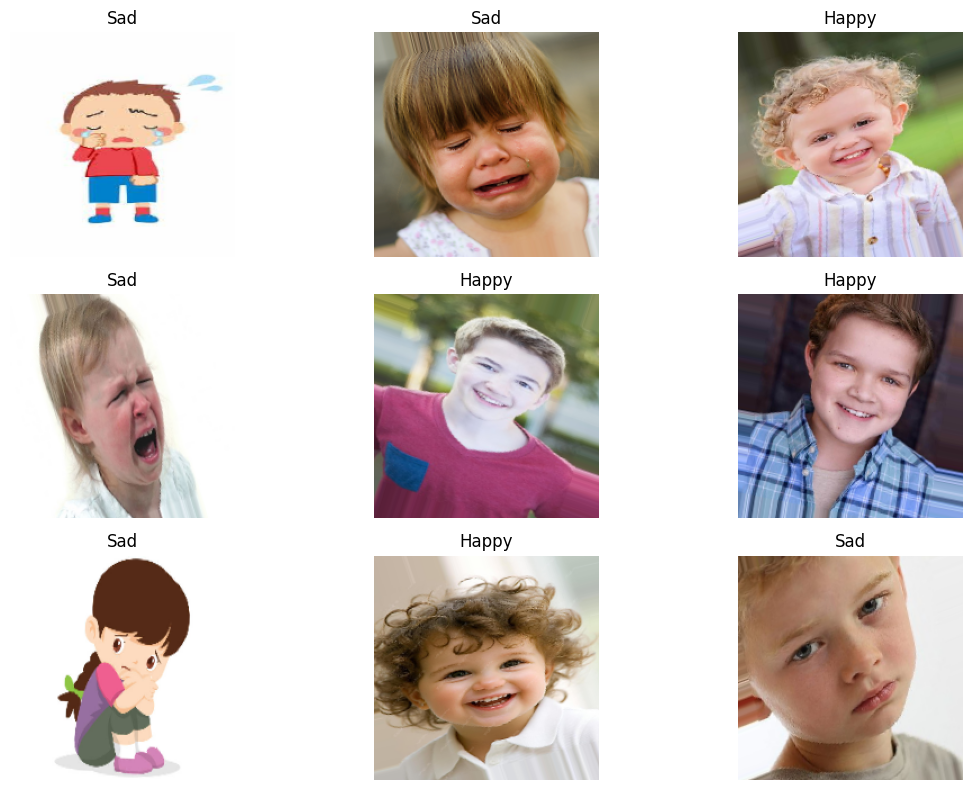

In [10]:
# Display Sample Images
images, labels = next(train_dataset)

plt.figure(figsize=(12,8))

for i in range(9):

    plt.subplot(3,3,i+1)

    plt.imshow(images[i])

    plt.title("Happy" if labels[i]==0 else "Sad")

    plt.axis("off")

plt.tight_layout()

plt.show()

# Build CNN Model

In [11]:
model = Sequential()

In [12]:
# First Convolution Block
model.add(Conv2D(32, (3, 3), activation='relu', input_shape=(200, 200, 3)))
model.add(MaxPooling2D(pool_size=(2,2)))

c:\Users\ASUS\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [13]:
# Second Convolution Block
model.add(Conv2D(64, (3, 3), activation='relu', input_shape=(200, 200, 3)))
model.add(MaxPooling2D(pool_size=(2,2)))

In [14]:
# Third Convolution Block
model.add(Conv2D(128, (3, 3), activation='relu', input_shape=(200, 200, 3)))
model.add(MaxPooling2D(pool_size=(2,2)))

In [15]:
# Fourth Convolution Block
model.add(Conv2D(256, (3, 3), activation='relu', input_shape=(200, 200, 3)))
model.add(MaxPooling2D(pool_size=(2,2)))

In [16]:
# Flatten Layer
model.add(Flatten())

In [17]:
# Fully Connected Layers

model.add(Dense(512, activation='relu'))

model.add(Dropout(0.5))

model.add(Dense(128, activation='relu'))

model.add(Dropout(0.3))

In [18]:
# Output Layer

model.add(Dense(1, activation='sigmoid'))

In [19]:
# Summary
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 198, 198, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 99, 99, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 97, 97, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 48, 48, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 46, 46, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 23, 23, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 21, 21, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 10, 10, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25600)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │    13,107,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        65,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,561,921 (51.73 MB)

 Trainable params: 13,561,921 (51.73 MB)

 Non-trainable params: 0 (0.00 B)

In [20]:
# Compile the Model

model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [21]:
# Train the Model

history = model.fit(
    train_dataset,
    validation_data=validation_dataset,
    epochs=20,
    verbose=1
)

Epoch 1/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 12s 2s/step - accuracy: 0.5245 - loss: 0.6916 - val_accuracy: 0.2857 - val_loss: 0.7371
Epoch 2/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 6s 1s/step - accuracy: 0.5455 - loss: 0.7011 - val_accuracy: 0.2857 - val_loss: 0.7640
Epoch 3/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 7s 1s/step - accuracy: 0.5385 - loss: 0.7002 - val_accuracy: 0.4286 - val_loss: 0.6979
Epoch 4/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 7s 1s/step - accuracy: 0.5315 - loss: 0.7045 - val_accuracy: 0.7143 - val_loss: 0.6748
Epoch 5/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 7s 1s/step - accuracy: 0.4895 - loss: 0.7064 - val_accuracy: 0.7857 - val_loss: 0.6723
Epoch 6/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 7s 1s/step - accuracy: 0.4755 - loss: 0.7018 - val_accuracy: 0.5714 - val_loss: 0.6868
Epoch 7/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 7s 1s/step - accuracy: 0.5874 - loss: 0.6752 - val_accuracy: 0.4286 - val_loss: 0.6950
Epoch 8/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 7s 1s/step - accuracy: 0.5664 - loss: 0.6791 - val_accuracy: 0.2857 - val_loss: 0.7202
Epoch 9/20
5/5 

In [22]:
# Save the Model
model.save("face_emotion_model.h5")

print("Model Saved Successfully!")

Model Saved Successfully!


In [23]:
model.save("face_emotion_model.keras")

# Evaluate the Model

In [24]:
# Evaluate the model on validation data

loss, accuracy = model.evaluate(validation_dataset)

print("="*40)
print(f"Validation Loss     : {loss:.4f}")
print(f"Validation Accuracy : {accuracy*100:.2f}%")
print("="*40)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 293ms/step - accuracy: 0.7857 - loss: 0.5122
Validation Loss     : 0.5122
Validation Accuracy : 78.57%


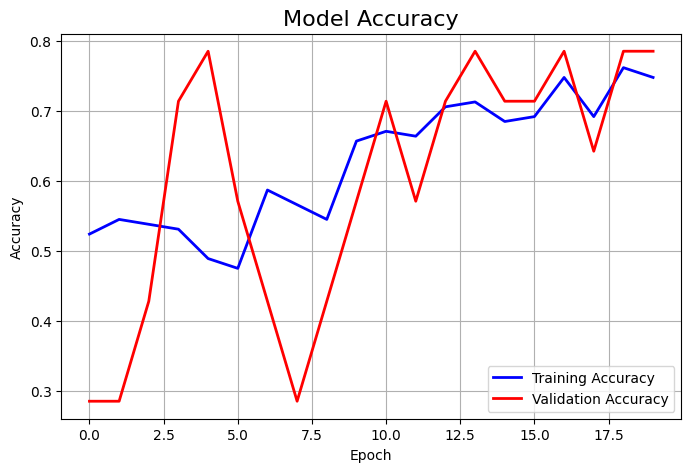

In [25]:
# Plot Training & Validation Accuracy

import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(history.history['accuracy'],
         color='blue',
         linewidth=2,
         label='Training Accuracy')

plt.plot(history.history['val_accuracy'],
         color='red',
         linewidth=2,
         label='Validation Accuracy')

plt.title("Model Accuracy", fontsize=16)

plt.xlabel("Epoch")

plt.ylabel("Accuracy")

plt.legend()

plt.grid(True)

plt.show()

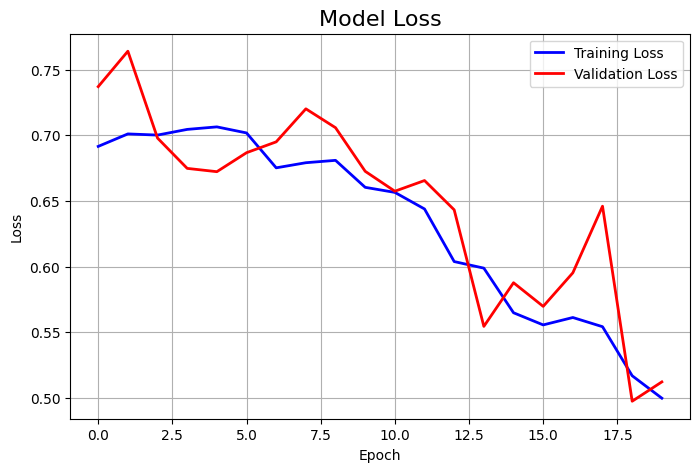

In [26]:
# Plot Training & Validation Loss

plt.figure(figsize=(8,5))

plt.plot(history.history['loss'],
         color='blue',
         linewidth=2,
         label='Training Loss')

plt.plot(history.history['val_loss'],
         color='red',
         linewidth=2,
         label='Validation Loss')

plt.title("Model Loss", fontsize=16)

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.legend()

plt.grid(True)

plt.show()

In [27]:
# Predict on Validation Dataset

import numpy as np

# Reset generator before prediction
validation_dataset.reset()

predictions = model.predict(validation_dataset)

predicted_classes = (predictions > 0.5).astype(int).flatten()

true_classes = validation_dataset.classes

class_labels = list(validation_dataset.class_indices.keys())

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 355ms/step


In [28]:
# Print Class Labels

print("Class Labels")

print(class_labels)

Class Labels
['happy', 'sad']


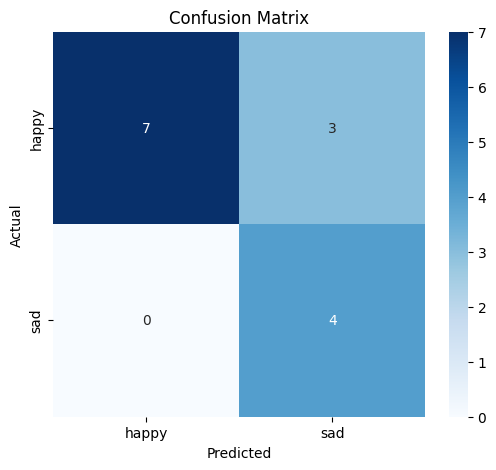

In [29]:
# Confusion Matrix

from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(true_classes, predicted_classes)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    cmap="Blues",
    fmt="d",
    xticklabels=class_labels,
    yticklabels=class_labels
)

plt.title("Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

In [30]:
# Classification Report

from sklearn.metrics import classification_report

print(classification_report(
    true_classes,
    predicted_classes,
    target_names=class_labels
))

              precision    recall  f1-score   support

       happy       1.00      0.70      0.82        10
         sad       0.57      1.00      0.73         4

    accuracy                           0.79        14
   macro avg       0.79      0.85      0.78        14
weighted avg       0.88      0.79      0.80        14



In [31]:
# Calculate Precision, Recall & F1 Score

from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score

precision = precision_score(true_classes, predicted_classes)

recall = recall_score(true_classes, predicted_classes)

f1 = f1_score(true_classes, predicted_classes)

print("Precision :", round(precision,4))

print("Recall :", round(recall,4))

print("F1 Score :", round(f1,4))

Precision : 0.5714
Recall : 1.0
F1 Score : 0.7273


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 296ms/step


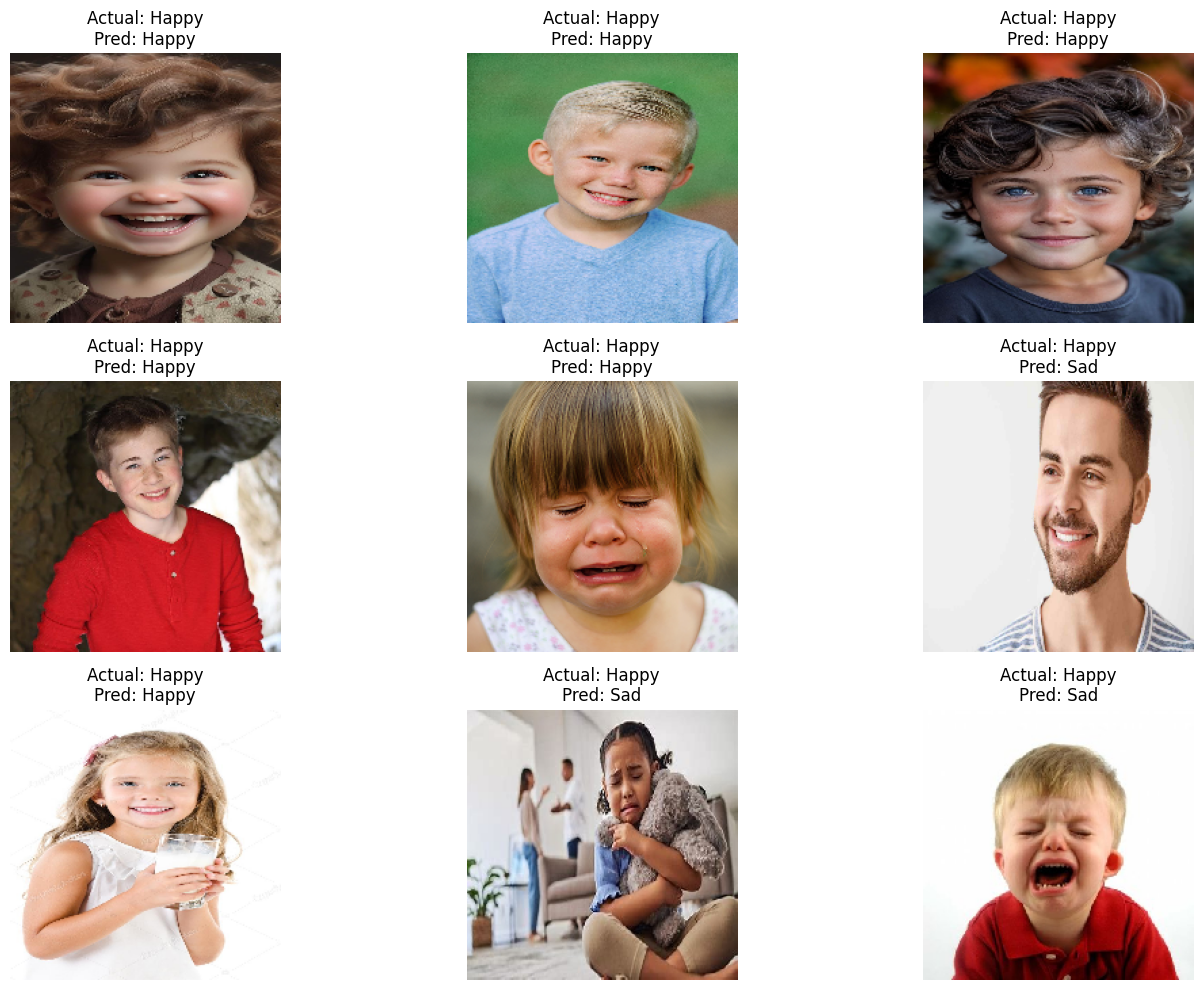

In [32]:
# Display Some Validation Predictions

images, labels = next(validation_dataset)

pred = model.predict(images)

pred = (pred > 0.5).astype(int)

plt.figure(figsize=(15,10))

for i in range(min(9, len(images))):

    plt.subplot(3,3,i+1)

    plt.imshow(images[i])

    actual = "Happy" if labels[i] == 0 else "Sad"

    predicted = "Happy" if pred[i] == 0 else "Sad"

    plt.title(f"Actual: {actual}\nPred: {predicted}")

    plt.axis("off")

plt.tight_layout()

plt.show()

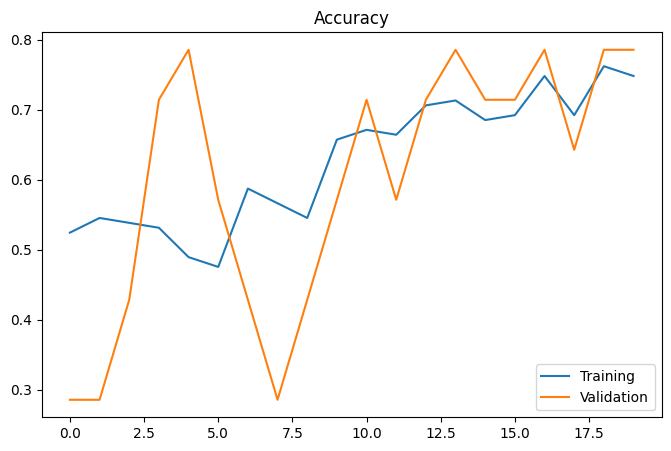

In [33]:
# Save Training Graphs

# Accuracy Graph

plt.figure(figsize=(8,5))

plt.plot(history.history['accuracy'])

plt.plot(history.history['val_accuracy'])

plt.legend(['Training','Validation'])

plt.title("Accuracy")

plt.savefig("training_accuracy.png")

plt.show()

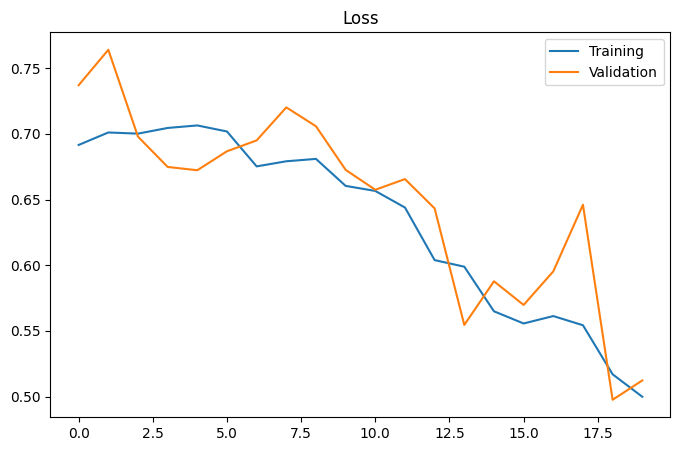

In [34]:
# Loss Graph

plt.figure(figsize=(8,5))

plt.plot(history.history['loss'])

plt.plot(history.history['val_loss'])

plt.legend(['Training','Validation'])

plt.title("Loss")

plt.savefig("training_loss.png")

plt.show()

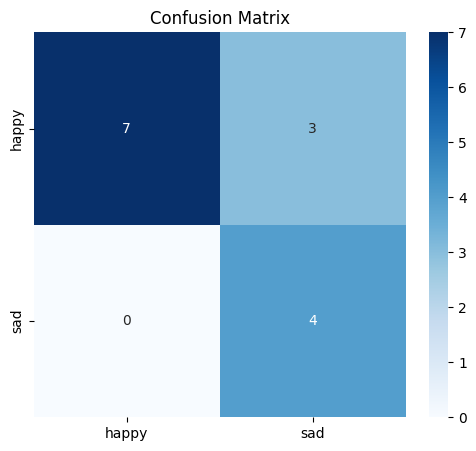

In [35]:
# confusion matrix graph
plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    cmap='Blues',
    fmt='d',
    xticklabels=class_labels,
    yticklabels=class_labels
)

plt.title("Confusion Matrix")

plt.savefig("confusion_matrix.png")

plt.show()